In [1]:
import pickle
import pandas as pd
import xarray as xr
import numpy as np

In [3]:
df_parametros = pd.read_csv("outputs/syntetic_tracks_7r_params.csv")
xds_post = xr.open_dataset("outputs/Vars_postprocessed_new_OK.nc")

# df = pd.read_csv("outputs/selected_cases_MDA.csv", header=None)
# selected_cases = df.iloc[:, 0].tolist()[:3000]
variables = list(xds_post.data_vars.keys())

['Hsig', 'TPsmoo', 'Windv_x', 'Windv_y', 'Dir_x', 'Dir_y']

In [ ]:
df_parametros = pd.read_csv("outputs/syntetic_tracks_7r_params.csv")

df_parametros_reconstruct = df_parametros.drop(columns=['date_furthest'])
variables = ['Hsig', 'TPsmoo', 'Windv_x', 'Windv_y', 'Dir_x', 'Dir_y']

ds_predicted_test_all = {}

for var in variables:

    with open(f"outputs/pca_model_{var}_OK.pkl", "rb") as f:
        pca_output_all = pickle.load(f)

    with open(f"outputs/rbf_model_{var}_OK.pkl", "rb") as f:
        rbf_model = pickle.load(f)

    predictions = rbf_model.predict(dataset=df_parametros_reconstruct)

    ds_predicted_test = xr.Dataset(
        {"PCs": (("case_num", "n_component"), predictions.values)},
        coords={
            "case_num": df_parametros_reconstruct.index.values,
            "n_component": np.arange(predictions.shape[1]),
        },
    )

    da = list(pca_output_all.inverse_transform(ds_predicted_test).data_vars.values())[0]

    ds_predicted_test_all[var] = da


# concatenation into dataset
ds_predicted_test_all = xr.Dataset(ds_predicted_test_all)

INFO:RBF:Reconstructing data using current sigma values.
INFO:RBF:Checking for NaNs in subset data
INFO:RBF:Preprocessing subset data
INFO:RBF:Normalizing subset data
INFO:RBF:Proposed max custom scaler for distance_entrance is lower than datapoint
INFO:RBF:Proposed min custom scaler for azimuth_exit is bigger than datapoint
INFO:RBF:Proposed max custom scaler for p_entrance_hPa is lower than datapoint


INFO:RBF:Proposed min custom scaler for p_exit_hPa is bigger than datapoint
INFO:RBF:Proposed max custom scaler for p_exit_hPa is lower than datapoint
INFO:RBF:Subset data preprocessed successfully
INFO:RBF:Interpolating target variable PC1
INFO:RBF:Interpolating target variable PC2
INFO:RBF:Interpolating target variable PC3
INFO:RBF:Interpolating target variable PC4
INFO:RBF:Interpolating target variable PC5
INFO:RBF:Interpolating target variable PC6
INFO:RBF:Interpolating target variable PC7
INFO:RBF:Interpolating target variable PC8
INFO:RBF:Interpolating target variable PC9
INFO:RBF:Interpolating target variable PC10
INFO:RBF:Interpolating target variable PC11
INFO:RBF:Interpolating target variable PC12
INFO:RBF:Interpolating target variable PC13
INFO:RBF:Interpolating target variable PC14
INFO:RBF:Interpolating target variable PC15
INFO:RBF:Interpolating target variable PC16
INFO:RBF:Interpolating target variable PC17
INFO:RBF:Interpolating target variable PC18
INFO:RBF:Interpolat

In [ ]:
ds_predicted_test_all.to_netcdf("outputs/predicted_syntetic_all_OK.nc")

In [70]:
ds_predicted_test_all = xr.open_dataset("outputs/predicted_syntetic_all_OK.nc")

ds_predicted_test_all["Dir"] = (360 - np.arctan2(ds_predicted_test_all["Dir_x"], ds_predicted_test_all["Dir_y"]) * 180 / np.pi + 90) % 360

ds_predicted_test_all = ds_predicted_test_all.drop_vars(["Dir_x", "Dir_y"])

In [49]:
ds_predicted_test_all

<xarray.Dataset> Size: 51MB
Dimensions:   (case_num: 13184, time: 24, point: 4)
Coordinates:
  * case_num  (case_num) int64 105kB 0 1 2 3 4 ... 13179 13180 13181 13182 13183
  * time      (time) int64 192B 0 1 2 3 4 5 6 7 8 ... 15 16 17 18 19 20 21 22 23
  * point     (point) <U7 112B 'point_1' 'point_2' 'point_3' 'point_4'
Data variables:
    Hsig      (case_num, time, point) float64 10MB 0.0137 0.01961 ... 5.681
    TPsmoo    (case_num, time, point) float64 10MB 2.488 2.266 ... 8.705 10.39
    Windv_x   (case_num, time, point) float64 10MB -0.6555 -0.6438 ... -15.55
    Windv_y   (case_num, time, point) float64 10MB -1.574 -1.703 ... -12.17
    Dir       (case_num, time, point) float64 10MB 22.59 22.52 ... -0.0009508

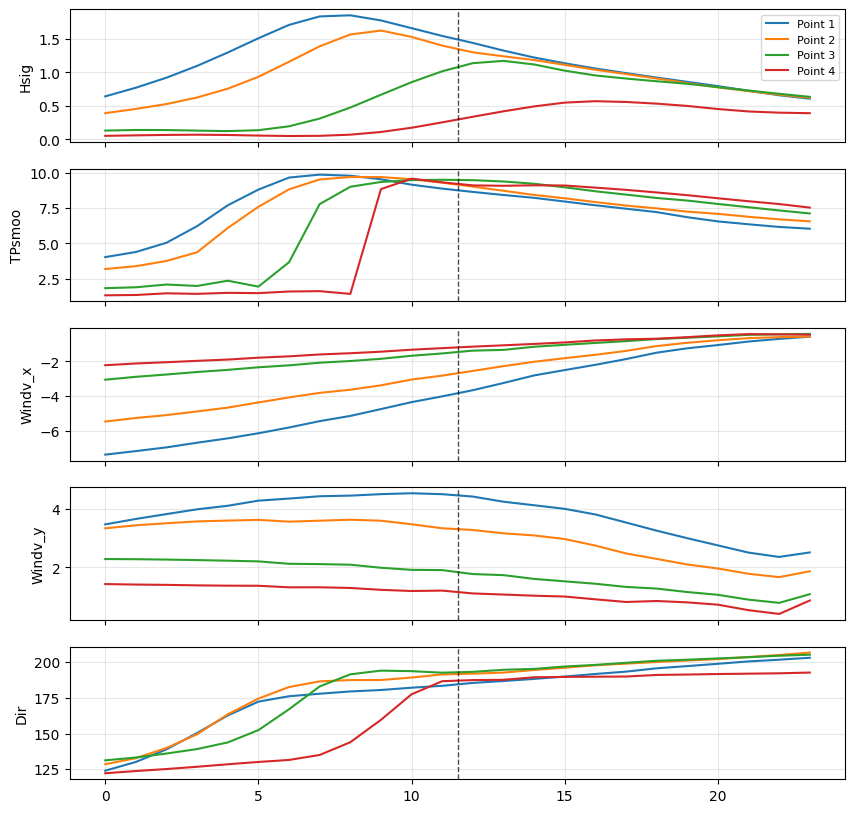

In [ ]:
import matplotlib.pyplot as plt

ds_case = ds_predicted_test_all.sel(case_num = 122)
common_time = ds_case.time.values
n_rows = len(ds_case.data_vars)
fig, axes = plt.subplots(n_rows, 1, figsize=(10, 2 * n_rows), sharex=True)
axes = np.atleast_2d(axes)
variables = list(ds_case.data_vars.keys())
time_mean = common_time.mean()

point_names = ["Point 1", "Point 2", "Point 3", "Point 4"]

for k, var in enumerate(variables):
    ax = axes.flat[k]
    arr = ds_case[var].values
    for j in range(arr.shape[1]):
        ax.plot(common_time, arr[:, j], label=point_names[j])
    ax.axvline(time_mean, color="k", ls="--", lw=1, alpha=0.7)
    ax.set_ylabel(var)
    if k == 0:
        ax.legend(loc="best", fontsize=8)
    ax.grid(True, alpha=0.3)

In [72]:
ds_predicted_test_all.to_netcdf("outputs/predicted_syntetic_all_OK_5vars.nc")